## Config

In [1]:
class Config:
    name_v1 = "lgb baseline"
    model_params = dict(objective="mae",
                        n_estimators=5000,
                        num_leaves=31,
                        random_state=2021,
                        importance_type="gain",
                        colsample_bytree=0.3,
                        learning_rate=0.5
                       )
    fit_params = dict(early_stopping_rounds=100, verbose=100)
    n_fold = 3
    seeds = [2021]
    target_col = "pressure"
    debug = False

## Library

In [2]:
import os
import joblib
import logging
import warnings
import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn import model_selection
from sklearn.metrics import mean_absolute_error

from lightgbm import LGBMModel
from matplotlib_venn import venn2
from tqdm import tqdm

In [3]:
class Logger:
    """save log"""
    def __init__(self, path):
        self.general_logger = logging.getLogger(path)
        stream_handler = logging.StreamHandler()
        file_general_handler = logging.FileHandler(os.path.join(path, 'Experiment.log'))
        if len(self.general_logger.handlers) == 0:
            self.general_logger.addHandler(stream_handler)
            self.general_logger.addHandler(file_general_handler)
            self.general_logger.setLevel(logging.INFO)

    def info(self, message):
        # display time
        self.general_logger.info('[{}] - {}'.format(self.now_string(), message))

    @staticmethod
    def now_string():
        return str(datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
    
    
class Util:
    """save & load"""
    @classmethod
    def dump(cls, value, path):
        joblib.dump(value, path, compress=True)

    @classmethod
    def load(cls, path):
        return joblib.load(path)
    
    
class HorizontalDisplay:
    """display dataframe"""
    def __init__(self, *args):
        self.args = args

    def _repr_html_(self):
        template = '<div style="float: left; padding: 10px;">{0}</div>'
        return "\n".join(template.format(arg._repr_html_())
                         for arg in self.args)
    
    
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2 
    dfs = []
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    dfs.append(df[col].astype(np.int8))
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    dfs.append(df[col].astype(np.int16))
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    dfs.append(df[col].astype(np.int32))
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    dfs.append(df[col].astype(np.int64) ) 
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    dfs.append(df[col].astype(np.float16))
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    dfs.append(df[col].astype(np.float32))
                else:
                    dfs.append(df[col].astype(np.float64))
        else:
            dfs.append(df[col])
    
    df_out = pd.concat(dfs, axis=1)
    if verbose:
        end_mem = df_out.memory_usage().sum() / 1024**2
        num_reduction = str(100 * (start_mem - end_mem) / start_mem)
        print(f'Mem. usage decreased to {str(end_mem)[:3]}Mb:  {num_reduction[:2]}% reduction')
    return df_out

## SetUp

In [4]:
INPUT = "../input/ventilator-pressure-prediction"
EXP = "./"
EXP_MODEL = os.path.join(EXP, "model")
EXP_FIG = os.path.join(EXP, "fig")
EXP_PREDS = os.path.join(EXP, "preds")

# make dirs
for d in [EXP_MODEL, EXP_FIG, EXP_PREDS]:
    os.makedirs(d, exist_ok=True)
    
# utils
logger = Logger(EXP)
warnings.filterwarnings("ignore")
sns.set(style='whitegrid')

## Load Data

In [5]:
train = pd.read_csv(os.path.join(INPUT, "train.csv"))
test = pd.read_csv(os.path.join(INPUT, "test.csv"))
sample_submission = pd.read_csv(os.path.join(INPUT, "sample_submission.csv"))

if Config.debug:
    train = train[train["breath_id"].isin(np.random.choice(train["breath_id"].unique(), 100))].reset_index(drop=True)
    test = test[test["breath_id"].isin(np.random.choice(test["breath_id"].unique(), 100))].reset_index(drop=True)
    sample_submission = sample_submission[sample_submission["id"].isin(test["id"].tolist())].reset_index(drop=True)

## Simple EDA

In [6]:
HorizontalDisplay(train, test, sample_submission)

,id,breath_id,R,C,time_step,u_in,u_out,pressure
0,1,1,20,50,0.000000,0.083334,0,5.837492
1,2,1,20,50,0.033652,18.383041,0,5.907794
2,3,1,20,50,0.067514,22.509278,0,7.876254
3,4,1,20,50,0.101542,22.808822,0,11.742872
4,5,1,20,50,0.135756,25.355850,0,12.234987
...,...,...,...,...,...,...,...,...
6035995,6035996,125749,50,10,2.504603,1.489714,1,3.869032
6035996,6035997,125749,50,10,2.537961,1.488497,1,3.869032
6035997,6035998,125749,50,10,2.571408,1.558978,1,3.798729
6035998,6035999,125749,50,10,2.604744,1.272663,1,4.079938


In [7]:
data = pd.concat([train, test]).reset_index(drop=True)
HorizontalDisplay(
    data["breath_id"].value_counts().to_frame(), 
    data["R"].value_counts().to_frame(),
    data["C"].value_counts().to_frame()
)

,breath_id
1,80
20976,80
20970,80
20968,80
20967,80
...,...
69871,80
69870,80
69869,80
69866,80


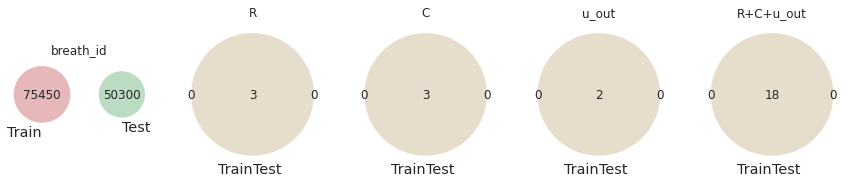

In [8]:
def plot_intersection(left, right, column, set_labels, ax=None):
    left_set = set(left[column])
    right_set = set(right[column])
    venn2(subsets=(left_set, right_set), set_labels=set_labels, ax=ax)
    return ax


def plot_right_left_intersection(train_df, test_df, columns='__all__'):
    """visualize venn(by nyk510)"""
    if columns == '__all__':
        columns = set(train_df.columns) & set(test_df.columns)

    columns = list(columns)
    nfigs = len(columns)
    ncols = 5
    nrows = - (- nfigs // ncols)
    fig, axes = plt.subplots(figsize=(3 * ncols, 3 * nrows), ncols=ncols, nrows=nrows)
    axes = np.ravel(axes)
    for c, ax in zip(columns, axes):
        plot_intersection(train_df, test_df, column=c, set_labels=('Train', 'Test'), ax=ax)
        ax.set_title(c)
    return fig


train["R+C+u_out"] = train["R"].astype(str) +"+"+ train["C"].astype(str) + "+" + train["u_out"].astype(str)
test["R+C+u_out"] = test["R"].astype(str) +"+"+ test["C"].astype(str) + "+" + test["u_out"].astype(str)
fig = plot_right_left_intersection(train, test, columns=["breath_id", "R", "C", "u_out", "R+C+u_out"])

del train["R+C+u_out"], test["R+C+u_out"]

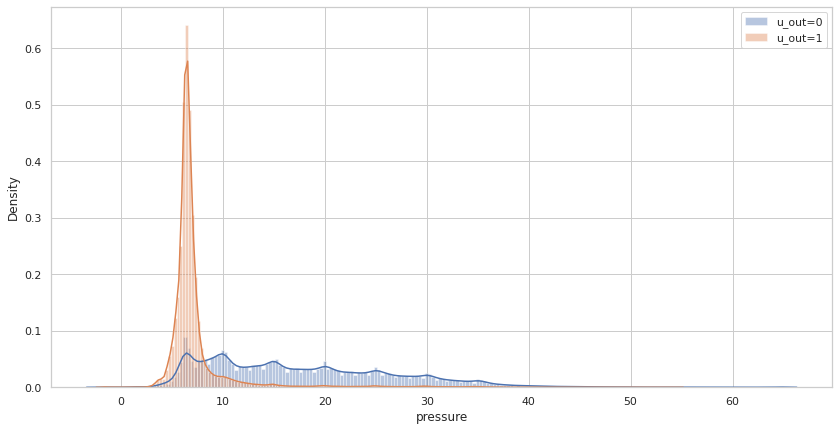

In [9]:
# pressure distribution (by u out)
fig, ax = plt.subplots(figsize=(14, 7))
ax = sns.distplot(train.loc[train["u_out"] == 0, "pressure"], ax=ax, label="u_out=0", bins=200)
ax = sns.distplot(train.loc[train["u_out"] == 1, "pressure"], ax=ax, label="u_out=1", bins=200)
ax.legend(loc='upper right')

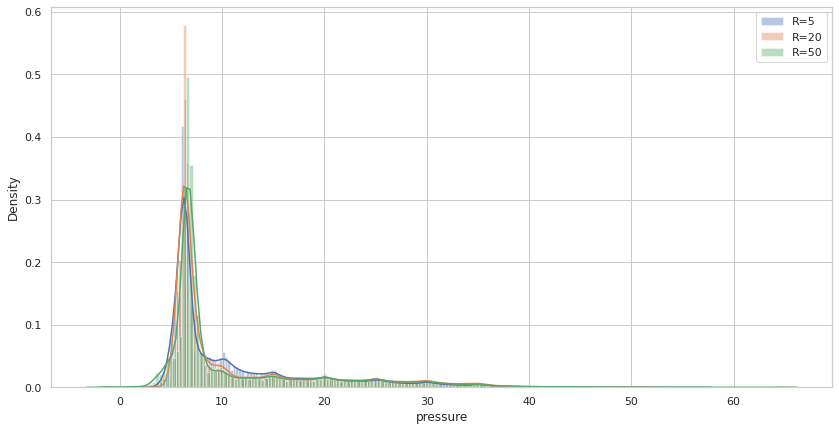

In [10]:
# pressur distribution (by R)
fig, ax = plt.subplots(figsize=(14, 7))
ax = sns.distplot(train.loc[train["R"] == 5, "pressure"], ax=ax, label="R=5", bins=200)
ax = sns.distplot(train.loc[train["R"] == 20, "pressure"], ax=ax, label="R=20", bins=200)
ax = sns.distplot(train.loc[train["R"] == 50, "pressure"], ax=ax, label="R=50", bins=200)
ax.legend(loc='upper right')

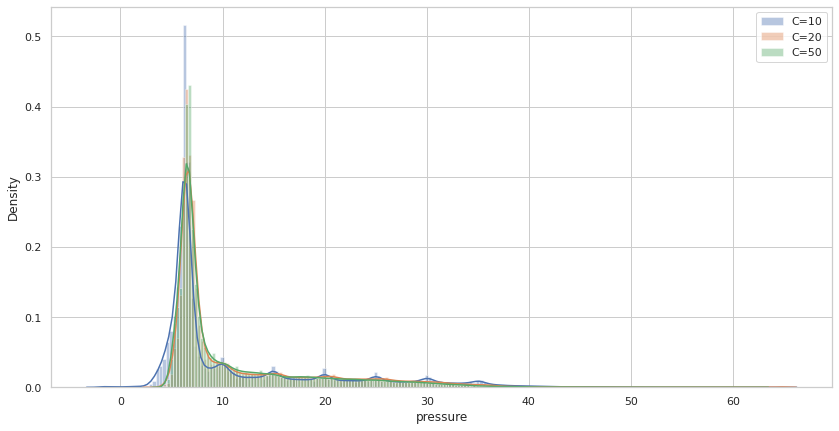

In [11]:
# pressure distribution (by C)
fig, ax = plt.subplots(figsize=(14, 7))
ax = sns.distplot(train.loc[train["C"] == 10, "pressure"], ax=ax, label="C=10", bins=200)
ax = sns.distplot(train.loc[train["C"] == 20, "pressure"], ax=ax, label="C=20", bins=200)
ax = sns.distplot(train.loc[train["C"] == 50, "pressure"], ax=ax, label="C=50", bins=200)
ax.legend(loc='upper right')

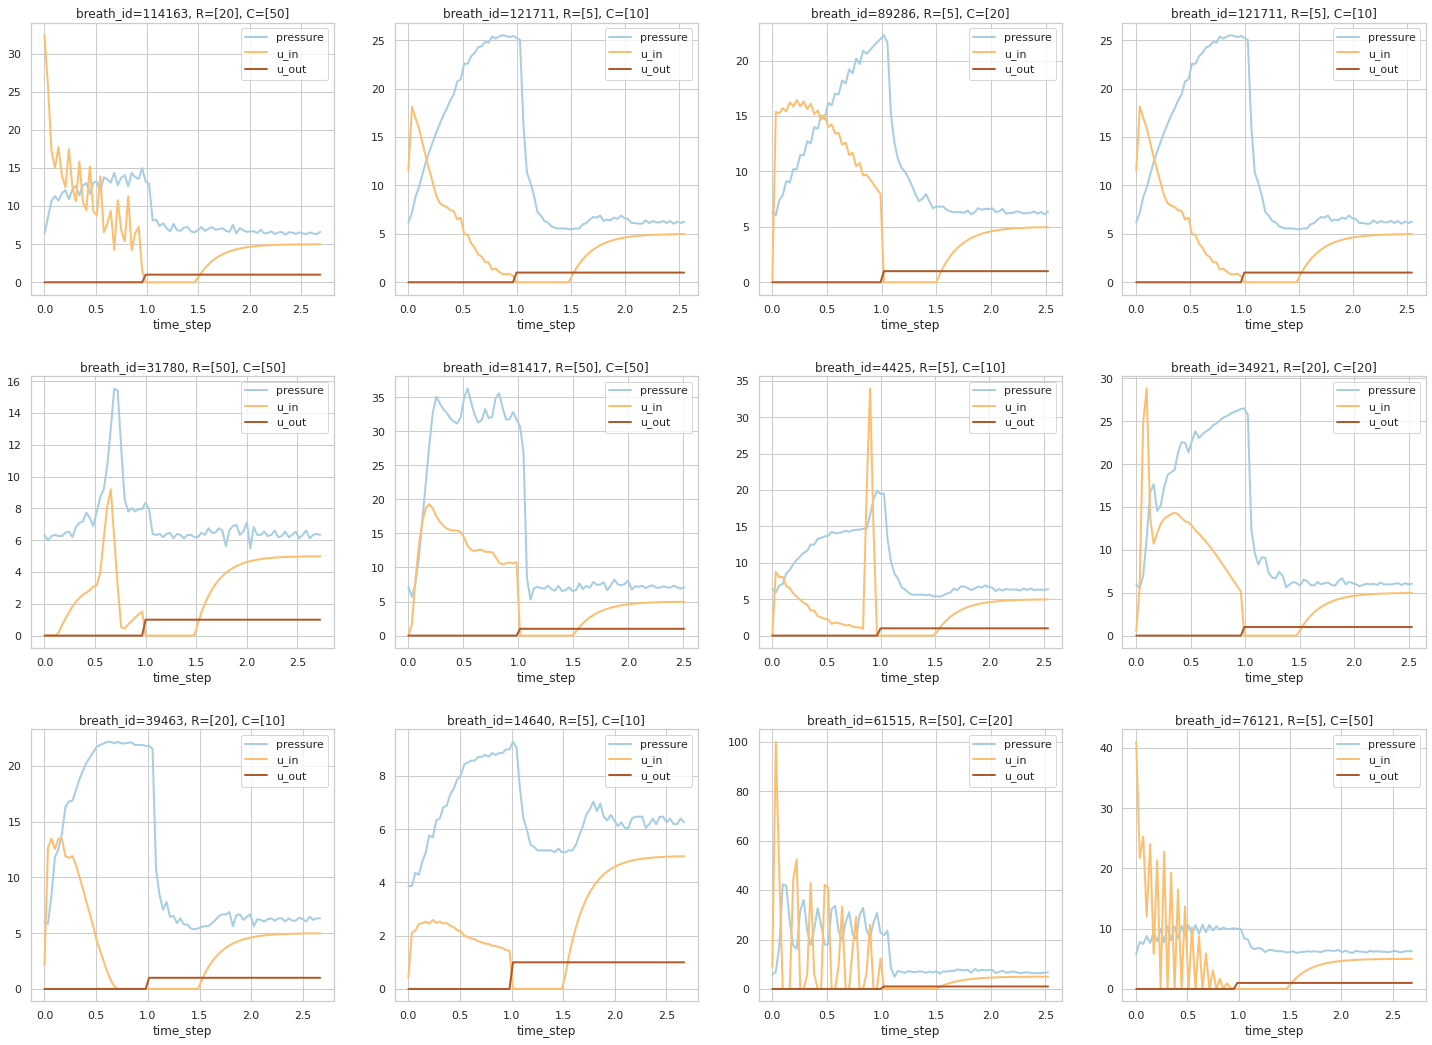

In [12]:
breath_ids = list(train["breath_id"].sample(12))
fig, axes = plt.subplots(figsize=(25, 18), ncols=4, nrows=3)
axes = np.ravel(axes)
for b, ax in zip(breath_ids, axes):
    _df = train[train["breath_id"]==b].copy()
    (_df
     .set_index("time_step")[["pressure", "u_in", "u_out"]]
     .plot(colormap='Paired',
           ax=ax,
           title=f"breath_id={b}, R={_df['R'].unique()}, C={_df['C'].unique()}", 
           linewidth=2)
    )
    
fig.subplots_adjust(hspace=0.3)

## Feature Enginnering

In [13]:
def aggregation(input_df, group_key, group_values, agg_methods):
    """ref:https://github.com/pfnet-research/xfeat/blob/master/xfeat/helper.py"""
    new_df = []
    for agg_method in agg_methods:
        for col in group_values:
            if callable(agg_method):
                agg_method_name = agg_method.__name__
            else:
                agg_method_name = agg_method
            new_col = f"agg_{agg_method_name}_{col}_grpby_{group_key}"
            df_agg = (input_df[[col] + [group_key]].groupby(group_key)[[col]].agg(agg_method))
            df_agg.columns = [new_col]
            new_df.append(df_agg)
            
    _df = pd.concat(new_df, axis=1).reset_index()
    output_df = pd.merge(input_df[[group_key]], _df, on=group_key, how="left")
    return output_df.drop(group_key, axis=1)

In [14]:
def get_raw_features(input_df):
    cols = [
        "R",
        "C",
        "time_step",
        "u_in",
        "u_out"
    ]
    output_df = input_df[cols].copy()
    return output_df


def get_cross_features(input_df):
    output_df = pd.DataFrame()
    output_df["R+C"] = (input_df["R"].astype(str) + input_df["C"].astype(str)).astype(int)
    return output_df


def get_shift_grpby_breath_id_features(input_df):
    # future feats
    shift_times = [-1, -2, 1, 2]
    group_key = "breath_id"
    
    group_values = ["u_in"]
    
    output_df = pd.DataFrame()
    for t in shift_times:
        _df = input_df.groupby(group_key)[group_values].shift(t)
        _df.columns = [f'shift={t}_{col}_grpby_{group_key}' for col in group_values]
        output_df = pd.concat([output_df, _df], axis=1)
    return output_df


def get_diff_grpby_breath_id_features(input_df):
    # future feats
    diff_times = [-1, -2, 1, 2]
    group_key = "breath_id"
    group_values = ["u_in"]
    
    output_df = pd.DataFrame()
    for t in diff_times:
        _df = input_df.groupby(group_key)[group_values].shift(t)
        _df.columns = [f'diff={t}_{col}_grpby_{group_key}' for col in group_values]
        output_df = pd.concat([output_df, _df], axis=1)
    return output_df


def get_cumsum_grpby_breath_id_features(input_df):
    group_key = "breath_id"
    group_values = ["time_step", "u_in", "u_out"]
    
    output_df = pd.DataFrame()
    for group_val in group_values:
        col_name = f"agg_cumsum_{group_val}_grpby_{group_key}"
        output_df[col_name] = input_df.groupby(group_key)[group_val].cumsum()
        
    return output_df


def get_time_step_cat_features(input_df):
    output_df = pd.DataFrame()    
    output_df["time_step_cat"] = input_df["time_step"].copy()
    output_df.loc[input_df["time_step"] < 1, "time_step_cat"] = 0
    output_df.loc[(1 < input_df["time_step"]) & (input_df["time_step"]< 1.5), "time_step_cat"] = 1
    output_df.loc[1.5 < input_df["time_step"], "time_step_cat"] = 2
    return output_df


def get_breath_id_pivot_features(input_df):
    _df = input_df[["breath_id", "time_step", "u_in"]].copy()
    _df["time_step_id"] =  _df.groupby(["breath_id"])["time_step"].rank(ascending=True)
    _df = pd.pivot_table(_df, columns="time_step_id", index="breath_id", values="u_in")
    _df.columns = [f"time_step_id={int(i):02}_u_in" for i in _df.columns]
    output_df = pd.merge(input_df[["breath_id"]], _df, left_on="breath_id", right_index=True, how="left")
    return output_df.drop("breath_id", axis=1)


def get_agg_breath_id_whole_features(whole_df):
    # do not have to use whole_df
    group_key = "breath_id"
    group_values = ["u_in"]
    agg_methods = ["mean", "std", "median", "max", "sum"]
    
    output_df = aggregation(whole_df, group_key, group_values, agg_methods)
    
    # z-score
    z_col_name = _get_agg_col_name(group_key, group_values, ["z-score"])
    m_col_name = _get_agg_col_name(group_key, group_values, ["mean"])
    s_col_name = _get_agg_col_name(group_key, group_values, ["std"])
    
    output_df[z_col_name] = ((whole_df[group_values].values - output_df[m_col_name].values) 
                             / (output_df[m_col_name].values + 1e-8))    
    return output_df


def _get_agg_col_name(group_key, group_values, agg_methods):
    out_cols = []
    for group_val in group_values:
        for agg_method in agg_methods:
            out_cols.append(f"agg_{agg_method}_{group_val}_grpby_{group_key}")
    return out_cols

In [15]:
def get_features(input_df):
    output_df = pd.DataFrame()
    funcs = [
        get_raw_features,
        get_cross_features,
        get_shift_grpby_breath_id_features,
        get_diff_grpby_breath_id_features,
        get_time_step_cat_features,
        get_breath_id_pivot_features,
        get_cumsum_grpby_breath_id_features
    ]
    for func in funcs:
        print(func.__name__)
        _df = func(input_df)
        _df = reduce_mem_usage(_df)
        output_df = pd.concat([output_df, _df], axis=1)
        
    return output_df


def get_whole_features(train, test):
    whole_df = pd.concat([train, test]).reset_index(drop=True)
    output_df = pd.DataFrame()
    funcs = [
        get_agg_breath_id_whole_features,
    ]
    
    if not funcs:
        return pd.DataFrame(), pd.DataFrame()
    
    for func in funcs:
        print(func.__name__)
        _df = func(whole_df)
        _df = reduce_mem_usage(_df)
        output_df = pd.concat([output_df, _df], axis=1)
        
    train_x = output_df.iloc[:len(train)]
    test_x = output_df.iloc[len(train):].reset_index(drop=True)
    
    return train_x, test_x
    
    
def preprocess(train, test):
    # whole feature
    train_x, test_x = get_whole_features(train, test)
    train_x = pd.concat([train_x, get_features(train)], axis=1)
    test_x = pd.concat([test_x, get_features(test)], axis=1)
    train_y = train[Config.target_col]
    return train_x, train_y, test_x

## Model

In [16]:
class LGBM:
    """MyLGBMModel"""
    def __init__(self, model_params={}, fit_params={}):
        self.model = None
        self.model_params = model_params
        self.fit_params = fit_params

    def build(self):
        self.model = LGBMModel(**self.model_params)
    
    def fit(self, tr_x, tr_y, va_x, va_y):
        self.model.fit(tr_x, tr_y, eval_set=[(va_x, va_y)], **self.fit_params)
    
    def predict(self, x):
        preds = self.model.predict(x)
        return preds

    def save(self, filepath):
        Util.dump(self.model, filepath + ".pkl")
    
    def load(self, filepath):
        self.model = Util.load(filepath + ".pkl")

## Funcs

In [17]:
def metrics(y_true, y_pred):
    # todo: expiratory phase is not scored (?)
    score = mean_absolute_error(y_true, y_pred)
    return score


class GroupKFold:
    """
    GroupKFold with random shuffle with a sklearn-like structure (by katsu1110)
    """
    def __init__(self, n_splits=4, shuffle=True, random_state=42):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state

    def get_n_splits(self, X=None, y=None, group=None):
        return self.n_splits

    def split(self, X=None, y=None, group=None):
        kf = model_selection.KFold(n_splits=self.n_splits, shuffle=self.shuffle, random_state=self.random_state)
        unique_ids = group.unique()
        for tr_group_idx, va_group_idx in kf.split(unique_ids):
            # split group
            tr_group, va_group = unique_ids[tr_group_idx], unique_ids[va_group_idx]
            train_idx = np.where(group.isin(tr_group))[0]
            val_idx = np.where(group.isin(va_group))[0]
            yield train_idx, val_idx

            
def gkf(X, group, n_splits, random_state):
    gkf = GroupKFold(n_splits=n_splits, random_state=random_state, shuffle=True)
    return list(gkf.split(X, group=group))


def train_cv_v1(X, y, model, cv, metrics, name, directory):
    oof = np.zeros(len(y))
    for i_fold, (tr_idx, va_idx) in enumerate(cv):
        filepath = os.path.join(directory, f"{name}_fold{i_fold+1}")
        tr_x, va_x = X.iloc[tr_idx].reset_index(drop=True), X.iloc[va_idx].reset_index(drop=True)
        tr_y, va_y = y.values[tr_idx], y.values[va_idx]

        model.build()
        model.fit(tr_x, tr_y, va_x, va_y)
        preds = model.predict(va_x)
        model.save(filepath)
        oof[va_idx] = preds

        score = metrics(np.array(va_y), np.array(preds))
        logger.info(f"{name}_fold{i_fold+1} >>> val socre:{score:.4f}")
    
    score = metrics(np.array(y), oof)
    logger.info(f"{name} >>> val score:{score:.4f}")
    return oof


def predict_cv_v1(X, model, name, directory):
    preds_fold = []
    for i_fold in range(Config.n_fold):
        filepath = os.path.join(directory, f"{name}_fold{i_fold+1}")
        logger.info(f"{name}_fold{i_fold+1} inference")
        model.build()
        model.load(filepath)
        preds = model.predict(X)
        preds_fold.append(preds)
    
    preds = np.mean(preds_fold, axis=0)
    return preds


def tree_importance(X, y, model, cv):
    """get importance"""
    feature_importance_df = pd.DataFrame()
    for i, (tr_idx, va_idx) in enumerate(cv):
        tr_x, va_x = X.values[tr_idx], X.values[va_idx]
        tr_y, va_y = y.values[tr_idx], y.values[va_idx]
        
        model.build()
        model.fit(tr_x, tr_y, va_x, va_y) 
        _df = pd.DataFrame()
        _df['feature_importance'] = model.model.feature_importances_
        _df['column'] = X.columns
        _df['fold'] = i + 1
        feature_importance_df = pd.concat([feature_importance_df, _df], axis=0, ignore_index=True)

    order = feature_importance_df.groupby('column') \
                .sum()[['feature_importance']] \
                .sort_values('feature_importance', ascending=False).index[:50]
    fig, ax = plt.subplots(figsize=(12, max(4, len(order) * .2)))
    sns.boxenplot(data=feature_importance_df, y='column', x='feature_importance', order=order, ax=ax,
                  palette='viridis')
    fig.tight_layout()
    ax.grid()
    ax.set_title('feature importance')
    fig.tight_layout()
    return fig, feature_importance_df


def plot_regression_result(y, oof, directory):
    fig, ax = plt.subplots(figsize=(8, 8))
    sns.distplot(y, label='y', color='cyan', ax=ax)
    sns.distplot(oof, label='oof', color="magenta", ax=ax)
    # sns.distplot(preds, label='preds', color="yellow", ax=ax, kde=True)
    
    ax.legend()
    ax.grid()
    ax.set_title("regression_result")
    fig.tight_layout()
    return fig

## Main

# ============= # Preprocess # ============= #
get_agg_breath_id_whole_features
Mem. usage decreased to 191Mb:  64% reduction
get_raw_features
Mem. usage decreased to 40.Mb:  82% reduction
get_cross_features
Mem. usage decreased to 11.Mb:  74% reduction
get_shift_grpby_breath_id_features
Mem. usage decreased to 46.Mb:  74% reduction
get_diff_grpby_breath_id_features
Mem. usage decreased to 46.Mb:  74% reduction
get_time_step_cat_features
Mem. usage decreased to 11.Mb:  74% reduction
get_breath_id_pivot_features
Mem. usage decreased to 921Mb:  74% reduction
get_cumsum_grpby_breath_id_features
Mem. usage decreased to 28.Mb:  79% reduction
get_raw_features
Mem. usage decreased to 26.Mb:  82% reduction
get_cross_features
Mem. usage decreased to 7.6Mb:  74% reduction
get_shift_grpby_breath_id_features
Mem. usage decreased to 30.Mb:  74% reduction
get_diff_grpby_breath_id_features
Mem. usage decreased to 30.Mb:  74% reduction
get_time_step_cat_features
Mem. usage decreased to 7.6Mb:  74% red

[2021-09-24 03:16:06] - lgb baseline-2021_fold1 >>> val socre:0.4813


Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 0.786361
[200]	valid_0's l1: 0.694766
[300]	valid_0's l1: 0.64422
[400]	valid_0's l1: 0.621406
[500]	valid_0's l1: 0.600838
[600]	valid_0's l1: 0.588464
[700]	valid_0's l1: 0.576328
[800]	valid_0's l1: 0.567105
[900]	valid_0's l1: 0.557583
[1000]	valid_0's l1: 0.549415
[1100]	valid_0's l1: 0.54277
[1200]	valid_0's l1: 0.537718
[1300]	valid_0's l1: 0.533004
[1400]	valid_0's l1: 0.529069
[1500]	valid_0's l1: 0.524822
[1600]	valid_0's l1: 0.521266
[1700]	valid_0's l1: 0.518037
[1800]	valid_0's l1: 0.515705
[1900]	valid_0's l1: 0.513505
[2000]	valid_0's l1: 0.511217
[2100]	valid_0's l1: 0.509303
[2200]	valid_0's l1: 0.507604
[2300]	valid_0's l1: 0.504856
[2400]	valid_0's l1: 0.50282
[2500]	valid_0's l1: 0.500677
[2600]	valid_0's l1: 0.499688
[2700]	valid_0's l1: 0.498035
[2800]	valid_0's l1: 0.496531
[2900]	valid_0's l1: 0.49509
[3000]	valid_0's l1: 0.493382
[3100]	valid_0's l1: 0.492141
[3200]	valid_0's l1: 

[2021-09-24 03:48:33] - lgb baseline-2021_fold2 >>> val socre:0.4781


Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 0.783497
[200]	valid_0's l1: 0.693145
[300]	valid_0's l1: 0.647067
[400]	valid_0's l1: 0.619382
[500]	valid_0's l1: 0.60184
[600]	valid_0's l1: 0.586759
[700]	valid_0's l1: 0.574723
[800]	valid_0's l1: 0.563428
[900]	valid_0's l1: 0.557432
[1000]	valid_0's l1: 0.550556
[1100]	valid_0's l1: 0.54444
[1200]	valid_0's l1: 0.539536
[1300]	valid_0's l1: 0.535573
[1400]	valid_0's l1: 0.530963
[1500]	valid_0's l1: 0.527015
[1600]	valid_0's l1: 0.52308
[1700]	valid_0's l1: 0.519728
[1800]	valid_0's l1: 0.517263
[1900]	valid_0's l1: 0.514793
[2000]	valid_0's l1: 0.512739
[2100]	valid_0's l1: 0.510248
[2200]	valid_0's l1: 0.508007
[2300]	valid_0's l1: 0.505863
[2400]	valid_0's l1: 0.503743
[2500]	valid_0's l1: 0.50181
[2600]	valid_0's l1: 0.500898
[2700]	valid_0's l1: 0.499381
[2800]	valid_0's l1: 0.498351
[2900]	valid_0's l1: 0.496878
[3000]	valid_0's l1: 0.495754
[3100]	valid_0's l1: 0.494732
[3200]	valid_0's l1: 

[2021-09-24 04:21:11] - lgb baseline-2021_fold3 >>> val socre:0.4815
[2021-09-24 04:21:11] - lgb baseline-2021 >>> val score:0.4803
[2021-09-24 04:21:32] - lgb baseline score:0.4803
[2021-09-24 04:22:25] - lgb baseline-2021_fold1 inference


# ============= # Inference # ============= #


[2021-09-24 04:29:28] - lgb baseline-2021_fold2 inference
[2021-09-24 04:36:30] - lgb baseline-2021_fold3 inference


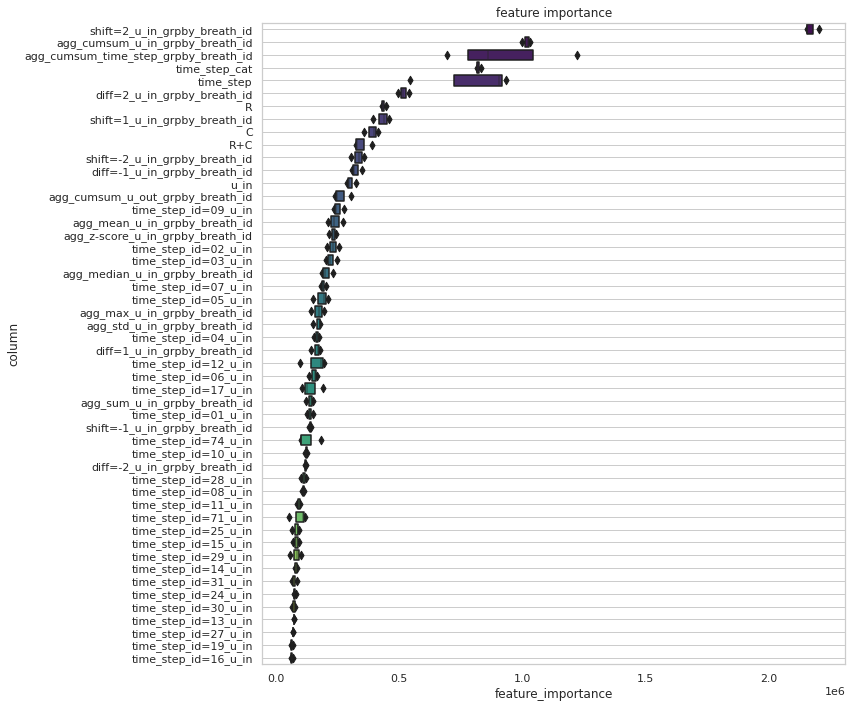

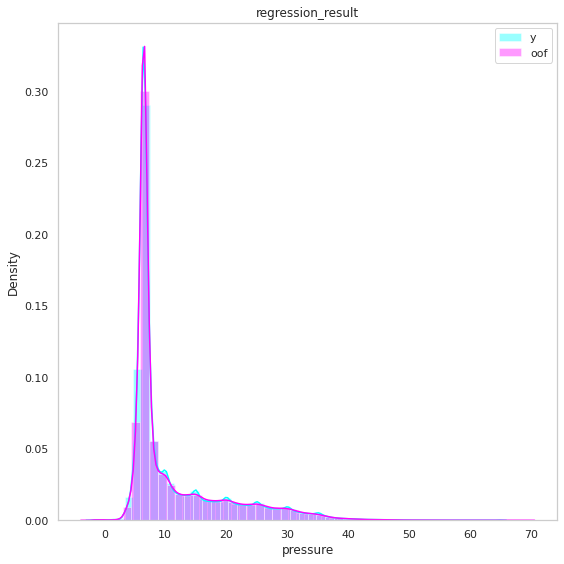

In [18]:
# preprocess
print("# ============= # Preprocess # ============= #")
train_x, train_y, test_x = preprocess(train, test)
print(train_x.shape)

# feature importace 
print("# ============= # Importance # ============= #")
fig, _df = tree_importance(
    X=train_x,
    y=train_y, 
     model=LGBM(model_params=Config.model_params,
                fit_params=Config.fit_params),
    cv=gkf(train, group=train["breath_id"],
           n_splits=3, random_state=Config.seeds[0])
)
fig.savefig(os.path.join(EXP_FIG, "importance.png"), dpi=300)

# training
print("# ============= # Training # ============= #")
oof_df = pd.DataFrame()
for seed in Config.seeds:
    name = f"{Config.name_v1}-{seed}"
    Config.model_params["random_state"] = seed
    oof = train_cv_v1(
        X=train_x,
        y=train_y, 
        model=LGBM(model_params=Config.model_params, 
                   fit_params=Config.fit_params),
        cv=gkf(train, 
               group=train["breath_id"],
               n_splits=Config.n_fold, 
               random_state=seed),
        metrics=metrics, 
        name=name, 
        directory=EXP_MODEL)

    oof_df[name] = oof
oof_df.to_csv(os.path.join(EXP_PREDS, "oof.csv"), index=False)

# get oof score
y_true = train[Config.target_col]
y_pred = oof_df.mean(axis=1)

oof_score = metrics(y_true, y_pred)
logger.info(f"{Config.name_v1} score:{oof_score:.4f}")

fig = plot_regression_result(y_true, y_pred, directory=EXP_FIG)
fig.savefig(os.path.join(EXP_FIG, "regression_result.png"), dpi=300)

# inference
print("# ============= # Inference # ============= #")
preds_df = pd.DataFrame()
for seed in Config.seeds:
    name = f"{Config.name_v1}-{seed}"
    preds = predict_cv_v1(
        test_x,
         model=LGBM(),
        name=name, 
        directory=EXP_MODEL
    )
    preds_df[name] = preds

preds_df.to_csv(os.path.join(EXP_PREDS, "preds.csv"), index=False)
test_pred = preds_df.mean(axis=1)

sample_submission['pressure'] = test_pred
sample_submission.to_csv('submission.csv', index=False) 